# Bank Customer Churn: Data Cleaning and Exploratory Analysis

**Goal:** understand which customers leave the bank (churn) and prepare a clean, model-ready dataset.

**Data:** `Bank_Churn_Messy.xlsx`, with two tabs that describe the same 10,000 customers (`Customer_Info` and `Account_Info`). Field definitions are in `Bank_Churn_Data_Dictionary.csv`. The target is `Exited` (1 = churned, 0 = stayed).

**Contents**

1. Load and combine the data
2. Clean the data (types, missing values, bad values, inconsistent labels)
3. Explore churn (target balance, categorical fields, numeric fields, deeper cuts)
4. Prepare the modelling dataset (drop columns, dummy variables, new feature)
5. Summary

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, MaxNLocator

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid.axis": "y",
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
})

# Same colour for the same group in every chart
STATUS_ORDER = ["Retained", "Churned"]
STATUS_COLORS = {"Retained": "#4C78A8", "Churned": "#E8833A"}
NUMERIC_FIELDS = ["CreditScore", "Age", "Tenure", "EstimatedSalary", "Balance", "NumOfProducts"]
MONEY_FIELDS = ["EstimatedSalary", "Balance"]
WHOLE_NUMBER_FIELDS = ["Tenure", "NumOfProducts"]
thousands = FuncFormatter(lambda x, _: f"{x:,.0f}")

## 1. Load and combine the data

### 1.1 Import both tabs of the Excel file

In [2]:
excel_file = pd.ExcelFile("Bank_Churn_Messy.xlsx")
customer_info = pd.read_excel(excel_file, sheet_name="Customer_Info")
account_info = pd.read_excel(excel_file, sheet_name="Account_Info")

print(f"Customer_Info: {customer_info.shape[0]:,} rows x {customer_info.shape[1]} columns")
print(f"Account_Info:  {account_info.shape[0]:,} rows x {account_info.shape[1]} columns")

Customer_Info: 10,001 rows x 8 columns
Account_Info:  10,002 rows x 7 columns


### 1.2 Left join `Account_Info` onto `Customer_Info`

Joining on `CustomerId` keeps every customer from `Customer_Info` and attaches their account details.

In [3]:
df = customer_info.merge(account_info, how="left", on="CustomerId")
print(f"After the join: {df.shape[0]:,} rows x {df.shape[1]} columns")

After the join: 10,004 rows x 14 columns


### 1.3 Remove duplicate rows and duplicate columns

The join has more rows than there are customers, so some customers appear more than once. If the repeats are exact copies, keeping the first one loses nothing.

In [4]:
n_repeated_ids = df.duplicated(subset="CustomerId").sum()
n_exact_copies = df.duplicated().sum()
print(f"Rows with a repeated CustomerId: {n_repeated_ids}")
print(f"Rows that are exact copies:      {n_exact_copies}")

df = df.drop_duplicates(subset="CustomerId", keep="first").reset_index(drop=True)
print(f"Unique customers kept:           {len(df):,}")

Rows with a repeated CustomerId: 4
Rows that are exact copies:      4
Unique customers kept:           10,000


Both tabs also contain `Tenure`, which pandas split into `Tenure_x` and `Tenure_y`. If the two are identical, one is redundant.

In [5]:
print("Tenure_x and Tenure_y identical:", df["Tenure_x"].equals(df["Tenure_y"]))

df = df.drop(columns="Tenure_y").rename(columns={"Tenure_x": "Tenure"})
df.head()

Tenure_x and Tenure_y identical: True


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,Yes,1
1,15647311,Hill,608,Spain,Female,41.0,1,€112542.58,€83807.86,1,Yes,Yes,0
2,15619304,Onio,502,French,Female,42.0,8,€113931.57,€159660.8,3,No,No,1
3,15701354,Boni,699,FRA,Female,39.0,1,€93826.63,€0.0,2,No,No,0
4,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1,€125510.82,1,Yes,Yes,0


## 2. Clean the data

### 2.1 Check the data types

`Balance` and `EstimatedSalary` are stored as text (they contain a `€` symbol), `HasCrCard` and `IsActiveMember` are `Yes`/`No` text, and `Age` is a float because it has missing values.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          9997 non-null   str    
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  str    
 4   Gender           10000 non-null  str    
 5   Age              9997 non-null   float64
 6   Tenure           10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  str    
 8   Balance          10000 non-null  str    
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  str    
 11  IsActiveMember   10000 non-null  str    
 12  Exited           10000 non-null  int64  
dtypes: float64(1), int64(5), str(7)
memory usage: 1015.8 KB


### 2.2 Fix the data types

In [7]:
# Money columns: strip the euro symbol, then convert to numbers
for col in ["Balance", "EstimatedSalary"]:
    df[col] = df[col].str.replace("€", "", regex=False).astype("float64")

# Yes/No text -> True/False, and 0/1 target -> True/False
for col in ["HasCrCard", "IsActiveMember"]:
    df[col] = df[col].eq("Yes")
df["Exited"] = df["Exited"].astype(bool)

df.dtypes.to_frame("dtype")

,dtype
CustomerId,int64
Surname,str
CreditScore,int64
Geography,str
Gender,str
Age,float64
Tenure,int64
EstimatedSalary,float64
Balance,float64
NumOfProducts,int64


### 2.3 Handle missing values

Only `Surname` (text) and `Age` (numeric) have gaps. Missing surnames become `"MISSING"` and missing ages become the median age. `Age` is then converted to whole numbers.

In [8]:
missing = df.isna().sum()
print("Missing values before:")
print(missing[missing > 0].to_string())

df["Surname"] = df["Surname"].fillna("MISSING")
df["Age"] = df["Age"].fillna(df["Age"].median()).astype("int64")

print(f"\nMissing values after: {df.isna().sum().sum()}")

Missing values before:
Surname    3
Age        3

Missing values after: 0


### 2.4 Look for extreme or nonsensical numeric values

In [9]:
df[NUMERIC_FIELDS].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.5,96.7,350.0,584.0,652.0,718.0,850.0
Age,10000.0,38.9,10.5,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,5.0,2.9,0.0,3.0,5.0,7.0,10.0
EstimatedSalary,10000.0,99762.2,60583.9,-999999.0,50910.7,100191.7,149388.2,199992.5
Balance,10000.0,76485.9,62397.4,0.0,0.0,97198.5,127644.2,250898.1
NumOfProducts,10000.0,1.5,0.6,1.0,1.0,1.0,2.0,4.0


Most ranges are plausible (credit score 350 to 850, age 18 to 92, tenure 0 to 10 years, 1 to 4 products). The exception is `EstimatedSalary`, whose minimum is **-999,999**. A salary cannot be negative, so this is a placeholder value. These are replaced with the column median.

In [10]:
negative_salary = df["EstimatedSalary"] < 0
print(f"Negative salaries found: {negative_salary.sum()}")

df.loc[negative_salary, "EstimatedSalary"] = df["EstimatedSalary"].median()
print(f"Minimum salary now: {df['EstimatedSalary'].min():,.2f}")

Negative salaries found: 3
Minimum salary now: 11.58


### 2.5 Standardise country names

`Geography` uses three spellings for France.

In [11]:
print("Before:", df["Geography"].value_counts().to_dict())

df["Geography"] = df["Geography"].replace({"FRA": "France", "French": "France"})

print("After: ", df["Geography"].value_counts().to_dict())

Before: {'Germany': 2509, 'Spain': 2477, 'France': 1741, 'French': 1655, 'FRA': 1618}
After:  {'France': 5014, 'Germany': 2509, 'Spain': 2477}


### 2.6 Data quality note: `HasCrCard` looks wrong

While checking the columns I compared `HasCrCard` with `IsActiveMember`. They should be unrelated fields.

In [12]:
same_value = (df["HasCrCard"] == df["IsActiveMember"]).mean()
print(f"Messy file: HasCrCard equals IsActiveMember in {same_value:.0%} of rows")

reference = pd.read_csv("Bank_Churn.csv")
print(f"Clean CSV:  {reference['HasCrCard'].mean():.1%} have a credit card, "
      f"{reference['IsActiveMember'].mean():.1%} are active members")

Messy file: HasCrCard equals IsActiveMember in 100% of rows
Clean CSV:  70.5% have a credit card, 51.5% are active members


In the messy file the two columns are identical for every customer, while in the clean CSV they differ (70.5% vs 51.5%). `HasCrCard` therefore appears to be a copy of `IsActiveMember` and **should not be trusted** until the source is checked. It is left in the dataset for now, but any model should be tested with and without it.

## 3. Explore churn

A plotting copy of the data with readable labels (`Retained` / `Churned`) is used for the charts below.

In [13]:
plot_df = df.assign(Status=df["Exited"].map({False: "Retained", True: "Churned"}))
overall_churn = df["Exited"].mean() * 100

### 3.1 Churners vs. non-churners

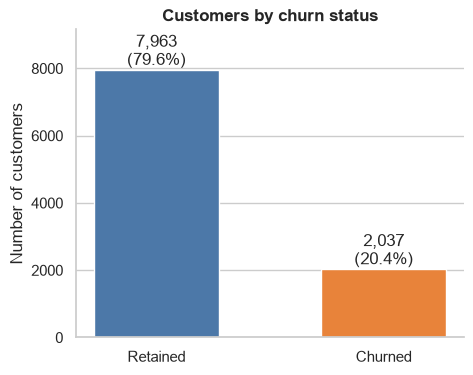

In [14]:
counts = plot_df["Status"].value_counts().reindex(STATUS_ORDER)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(counts.index, counts.values, color=[STATUS_COLORS[s] for s in counts.index], width=0.55)
ax.bar_label(bars, labels=[f"{n:,}\n({n / len(df):.1%})" for n in counts.values])
ax.set_ylim(0, counts.max() * 1.15)
ax.set(title="Customers by churn status", xlabel="", ylabel="Number of customers")
plt.show()

**Takeaway:** about 1 in 5 customers churned. The classes are imbalanced, so accuracy alone would be a misleading score for a future model: predicting "retained" for everyone would already be about 80% accurate.

### 3.2 Churn rate by `Geography` and `Gender`

Churn rate = customers who churned in a group / all customers in that group.

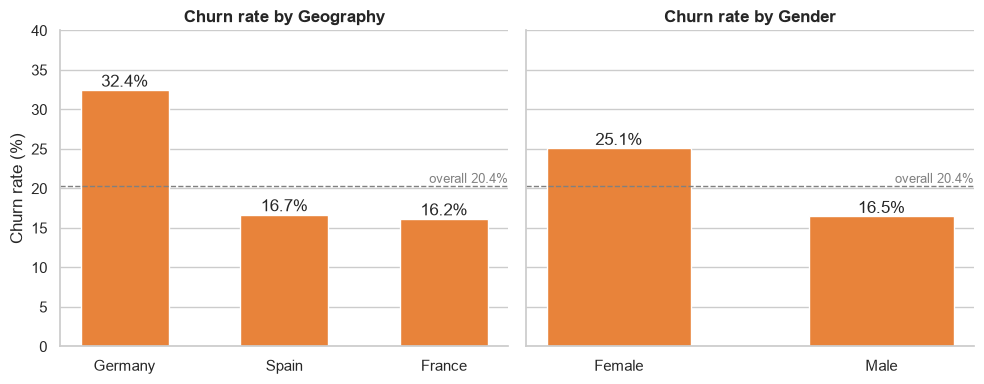

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, col in zip(axes, ["Geography", "Gender"]):
    rate = df.groupby(col)["Exited"].mean().mul(100).sort_values(ascending=False)
    bars = ax.bar(rate.index, rate.values, color=STATUS_COLORS["Churned"], width=0.55)
    ax.bar_label(bars, fmt="%.1f%%")
    ax.axhline(overall_churn, color="gray", linestyle="--", linewidth=1)
    ax.text(ax.get_xlim()[1], overall_churn, f"overall {overall_churn:.1f}%",
            ha="right", va="bottom", color="gray", fontsize=9)
    ax.set(title=f"Churn rate by {col}", xlabel="")

axes[0].set_ylabel("Churn rate (%)")
axes[0].set_ylim(0, 40)
plt.tight_layout()
plt.show()

**Takeaway:** German customers churn at about twice the rate of French and Spanish customers (roughly 32% vs 16%), and women churn more than men (roughly 25% vs 16%). These are patterns in the data, not proof of cause.

### 3.3 Box plots of each numeric field, churners vs. non-churners

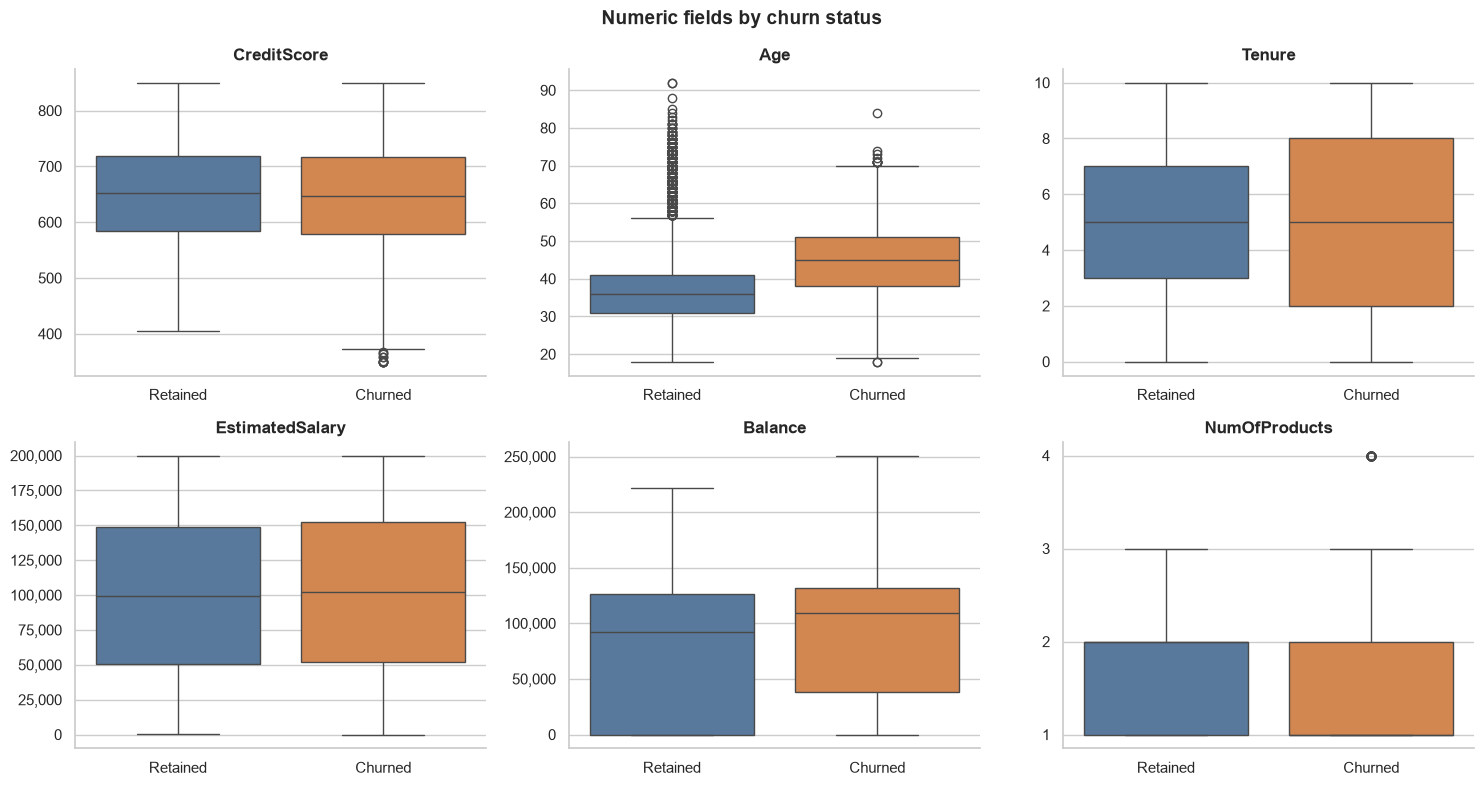

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, NUMERIC_FIELDS):
    sns.boxplot(data=plot_df, x="Status", y=col, order=STATUS_ORDER,
                hue="Status", hue_order=STATUS_ORDER, palette=STATUS_COLORS,
                legend=False, ax=ax)
    ax.set(title=col, xlabel="", ylabel="")
    if col in MONEY_FIELDS:
        ax.yaxis.set_major_formatter(thousands)
    if col in WHOLE_NUMBER_FIELDS:
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))

fig.suptitle("Numeric fields by churn status", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Takeaway:** `Age`, `Balance` and `NumOfProducts` separate the two groups. Churners are older (median about 45 vs 36), hold larger balances and typically have 1 product rather than 2. `CreditScore`, `Tenure` and `EstimatedSalary` look almost the same for both groups, so they are unlikely to be strong predictors on their own.

### 3.4 Histograms of each numeric field, churners vs. non-churners

Each chart shows the percentage of *each group* that falls in each bin, so the two groups can be compared even though there are about four times as many retained customers.

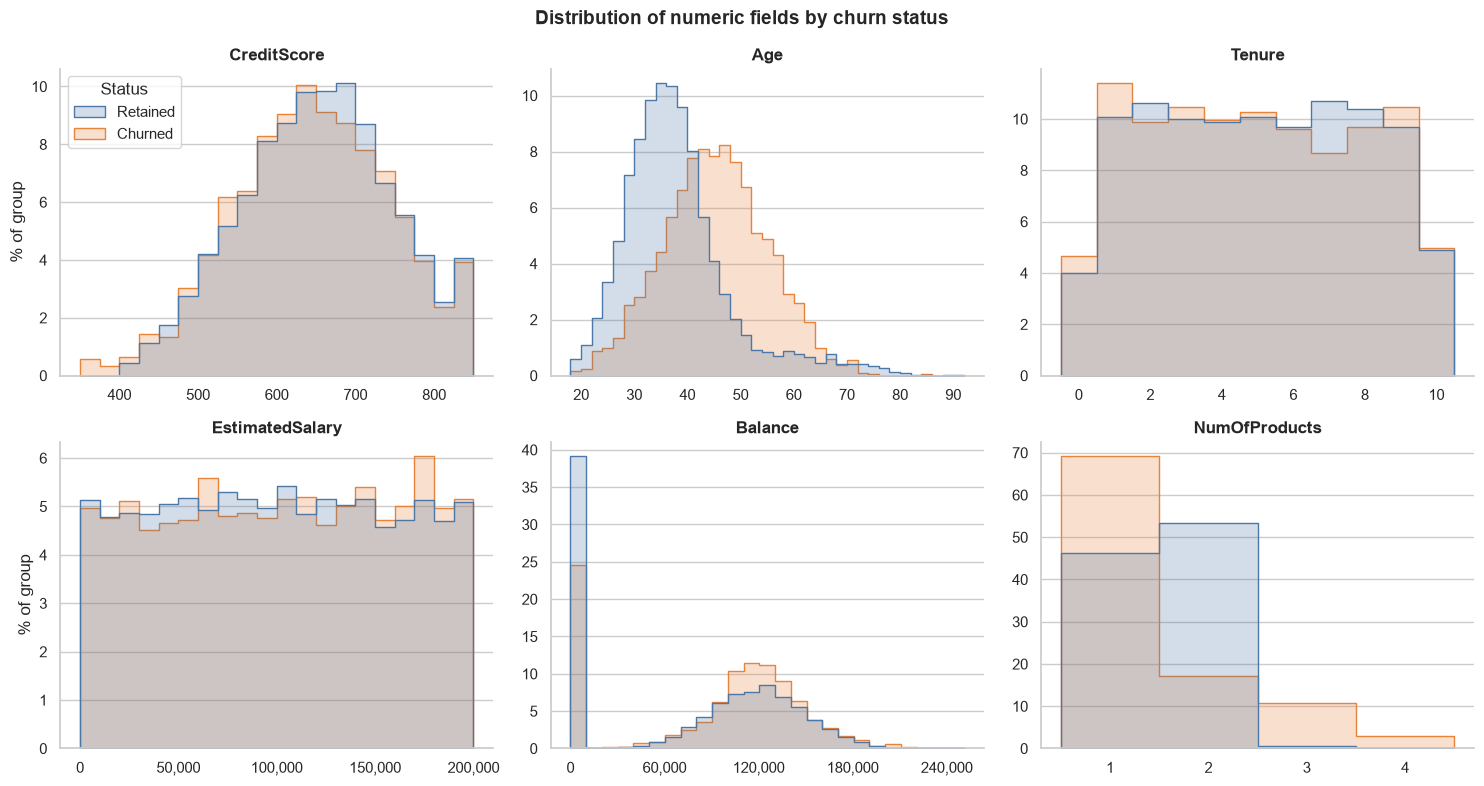

In [17]:
# Bin width per field; Tenure and NumOfProducts are whole numbers, so one bar per value
bin_widths = {"CreditScore": 25, "Age": 2, "EstimatedSalary": 10_000, "Balance": 10_000}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, (ax, col) in enumerate(zip(axes.flat, NUMERIC_FIELDS)):
    sns.histplot(data=plot_df, x=col, hue="Status", hue_order=STATUS_ORDER,
                 palette=STATUS_COLORS, stat="percent", common_norm=False, element="step",
                 discrete=col in WHOLE_NUMBER_FIELDS, binwidth=bin_widths.get(col), ax=ax)
    ax.set(title=col, xlabel="", ylabel="% of group" if i % 3 == 0 else "")
    if col in MONEY_FIELDS:
        ax.xaxis.set_major_locator(MaxNLocator(5))
        ax.xaxis.set_major_formatter(thousands)
    if col in WHOLE_NUMBER_FIELDS:
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    if i > 0:
        ax.get_legend().remove()

fig.suptitle("Distribution of numeric fields by churn status", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Takeaway:** the histograms agree with the box plots. The churner `Age` curve is shifted to the right (peaking in the 40s and 50s), and fewer churners have a zero balance. About 36% of all customers have a balance of exactly 0, which explains the tall spike at the left of the `Balance` chart.

### 3.5 Dig deeper: how big are the differences?

The box plots show *where* the groups differ. Churn rates by group show *how much*. Below, `Age` is cut into bands, and `NumOfProducts` and `IsActiveMember` (the fields that separated the groups) are shown as churn rates. Each label shows how many customers are in that group, because a rate based on very few customers is unreliable.

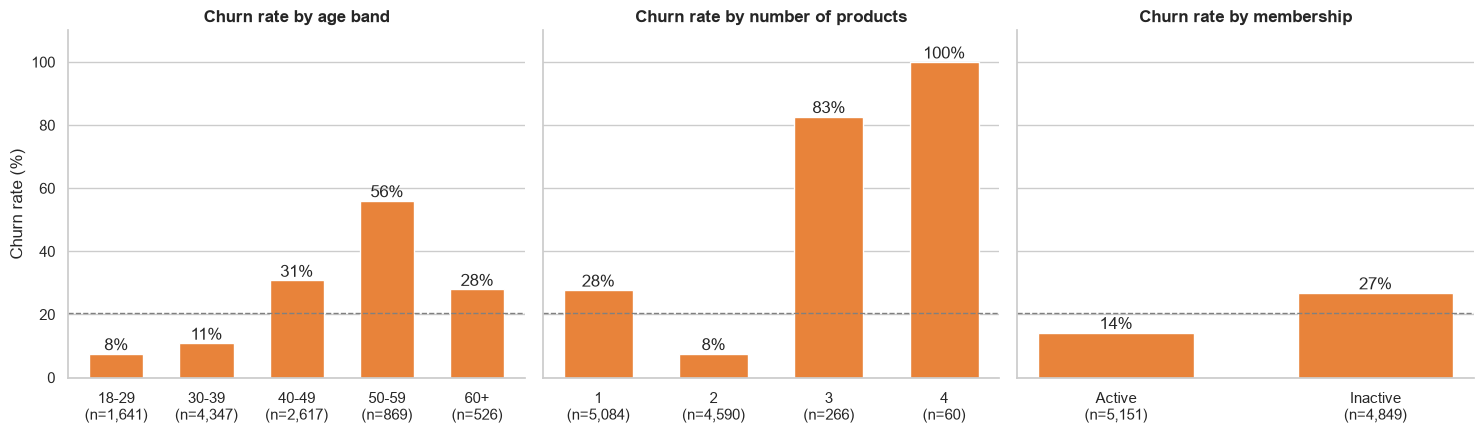

In [18]:
age_band = pd.cut(df["Age"], bins=[17, 29, 39, 49, 59, 100],
                  labels=["18-29", "30-39", "40-49", "50-59", "60+"])
groupings = {
    "age band": age_band,
    "number of products": df["NumOfProducts"],
    "membership": df["IsActiveMember"].map({True: "Active", False: "Inactive"}),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, (name, groups) in zip(axes, groupings.items()):
    stats = df.groupby(groups, observed=True)["Exited"].agg(["mean", "size"])
    labels = [f"{g}\n(n={n:,})" for g, n in zip(stats.index, stats["size"])]
    bars = ax.bar(labels, stats["mean"] * 100, color=STATUS_COLORS["Churned"], width=0.6)
    ax.bar_label(bars, fmt="%.0f%%")
    ax.axhline(overall_churn, color="gray", linestyle="--", linewidth=1)
    ax.set(title=f"Churn rate by {name}", xlabel="")

axes[0].set_ylabel("Churn rate (%)")
axes[0].set_ylim(0, 110)
plt.tight_layout()
plt.show()

**Takeaway:** churn climbs steeply with age: about 8% for under-30s and 11% for 30-39, then 31% for 40-49 and **56% for 50-59** (it falls back to 28% for 60+). Customers with 2 products churn the least (8%), against 28% for 1 product. Churn is very high for 3 and 4 products (83% and 100%), but only 266 and 60 customers hold them, so treat those two numbers with care. Inactive members churn at about twice the rate of active ones (27% vs 14%).

#### Is the balance finding really a country effect?

In 3.3 churners had higher balances, but balance is tangled up with country. Compare the countries below, and then compare them again using only customers who have a balance.

In [19]:
by_country = df.groupby("Geography").agg(
    customers=("Exited", "size"),
    churn_pct=("Exited", lambda s: s.mean() * 100),
    zero_balance_pct=("Balance", lambda s: (s == 0).mean() * 100),
)
by_country["churn_pct_with_balance"] = df[df["Balance"] > 0].groupby("Geography")["Exited"].mean() * 100
by_country = by_country.rename(columns={
    "customers": "Customers",
    "churn_pct": "Churn %",
    "zero_balance_pct": "Zero-balance %",
    "churn_pct_with_balance": "Churn % (balance > 0 only)",
}).round(1)
display(by_country)

germany_share = df.loc[df["Geography"] == "Germany", "Exited"].sum() / df["Exited"].sum()
print(f"Germany: {(df['Geography'] == 'Germany').mean():.0%} of customers, {germany_share:.0%} of churners")

,Customers,Churn %,Zero-balance %,Churn % (balance > 0 only)
Geography,,,,
France,5014,16.2,48.2,18.2
Germany,2509,32.4,0.0,32.4
Spain,2477,16.7,48.4,19.6


Germany: 25% of customers, 40% of churners


**Takeaway:** no German customer has a zero balance, while about half of French and Spanish customers do. So "has a balance" and "is German" overlap, and Germany also churns the most. That makes the balance gap in 3.3 only partly trustworthy. Comparing only customers who have a balance, Germany (32%) still churns far more than France (18%) and Spain (20%), so Germany is a real hotspot, not just a balance effect. Separating the effect of balance from the effect of country properly needs a model that looks at both together.

## 4. Prepare the modelling dataset

### 4.1 Drop columns that are not useful for modelling

`CustomerId` is just a label and `Surname` is a name, so neither can say anything general about churn. The result goes into a new dataframe, `df_model`, so the cleaned `df` stays available.

In [20]:
df_model = df.drop(columns=["CustomerId", "Surname"])
df_model.head()

,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,619,France,Female,42,2,101348.88,0.00,1,True,True,True
1,608,Spain,Female,41,1,112542.58,83807.86,1,True,True,False
2,502,France,Female,42,8,113931.57,159660.80,3,False,False,True
3,699,France,Female,39,1,93826.63,0.00,2,False,False,False
4,850,Spain,Female,43,2,79084.10,125510.82,1,True,True,False


### 4.2 Create dummy variables for the categorical fields

Models need numbers, so `Geography` and `Gender` become True/False columns. With `drop_first=True` one category per field is dropped (France, Female) to avoid redundant columns; it becomes the baseline, so all `False` means France / Female.

In [21]:
df_model = pd.get_dummies(df_model, columns=["Geography", "Gender"], drop_first=True)
df_model.head()

,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,101348.88,0.00,1,True,True,True,False,False,False
1,608,41,1,112542.58,83807.86,1,True,True,False,False,True,False
2,502,42,8,113931.57,159660.80,3,False,False,True,False,False,False
3,699,39,1,93826.63,0.00,2,False,False,False,False,False,False
4,850,43,2,79084.10,125510.82,1,True,True,False,False,True,False


### 4.3 New feature: `balance_v_income`

The customer's balance divided by their estimated salary, then compared between churners and non-churners.

In [22]:
df_model["balance_v_income"] = df_model["Balance"] / df_model["EstimatedSalary"]

df_model["balance_v_income"].describe().round(2).to_frame().T

,count,mean,std,min,25%,50%,75%,max
balance_v_income,10000.0,3.88,108.34,0.0,0.0,0.75,1.51,10614.66


The feature is extremely skewed: the median is below 1 but the maximum is above 10,000, because a few customers have a very small salary. Charting everything would squash the boxes flat, so the charts below show only the ratios under 10 (the number of customers left out is printed underneath). The feature itself keeps every row.

Customers not shown (ratio of 10 or more): 357


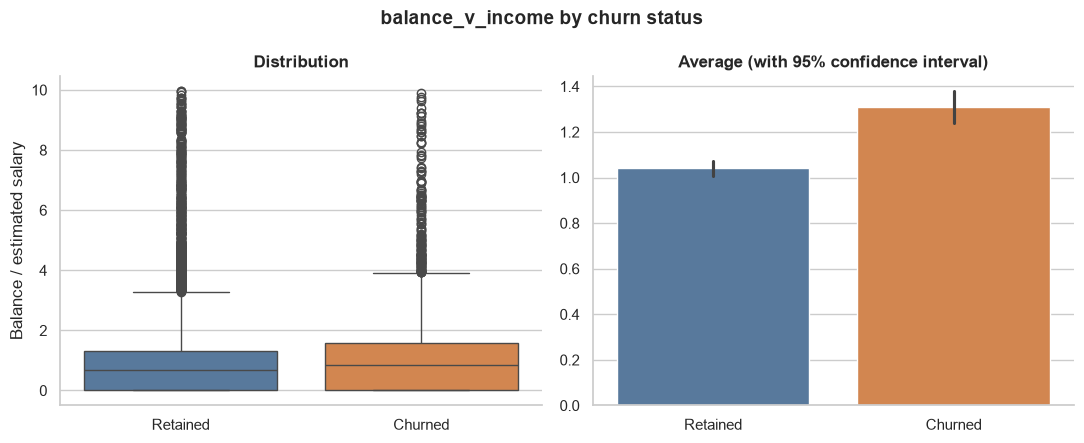

In [23]:
ratio_df = df_model.assign(Status=df_model["Exited"].map({False: "Retained", True: "Churned"}))
shown = ratio_df[ratio_df["balance_v_income"] < 10]
print(f"Customers not shown (ratio of 10 or more): {len(ratio_df) - len(shown)}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.boxplot(data=shown, x="Status", y="balance_v_income", order=STATUS_ORDER,
            hue="Status", hue_order=STATUS_ORDER, palette=STATUS_COLORS,
            legend=False, ax=axes[0])
axes[0].set(title="Distribution", xlabel="", ylabel="Balance / estimated salary")

sns.barplot(data=shown, x="Status", y="balance_v_income", order=STATUS_ORDER,
            hue="Status", hue_order=STATUS_ORDER, palette=STATUS_COLORS,
            legend=False, ax=axes[1])
axes[1].set(title="Average (with 95% confidence interval)", xlabel="", ylabel="")

fig.suptitle("balance_v_income by churn status", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Takeaway:** churners tend to hold a larger balance relative to their salary than customers who stay, in both the typical value and the average.

### 4.4 Final modelling dataset

In [24]:
print(f"df_model: {df_model.shape[0]:,} rows x {df_model.shape[1]} columns")
df_model.dtypes.to_frame("dtype")

df_model: 10,000 rows x 13 columns


,dtype
CreditScore,int64
Age,int64
Tenure,int64
EstimatedSalary,float64
Balance,float64
NumOfProducts,int64
HasCrCard,bool
IsActiveMember,bool
Exited,bool
Geography_Germany,bool


## 5. Summary

**Problem.** The bank lost about 20% of its 10,000 customers. Which customers are leaving, so that retention effort can be targeted?

**What I did.** I joined the two Excel tabs, removed 4 duplicate customers and a duplicated `Tenure` column, converted text to numbers and True/False, filled the few missing values, replaced three placeholder salaries of -999,999, and merged three spellings of France. While checking the data I found that `HasCrCard` is an exact copy of `IsActiveMember`, so it can't be trusted.

**What I found.**
- Churn is strongly tied to **age**: 31% for ages 40-49 and 56% for 50-59, against 8-11% for customers under 40.
- **Germany** churns at about twice the rate of France and Spain (32% vs 16-17%). It has 25% of customers but 40% of churners, and the gap remains when only customers with a balance are compared.
- Customers with **1 product** (28%) churn more than those with 2 products (8%). **Inactive members** churn at about twice the rate of active ones (27% vs 14%), and women churn more than men (25% vs 16%).
- `CreditScore`, `Tenure` and `EstimatedSalary` look the same for churners and non-churners.

**What this does not show.** These are patterns in one snapshot, not causes. Age, country, balance and activity overlap with each other (for example, balance and Germany), so each effect on its own is uncertain. The 3 and 4 product groups are small. The classes are imbalanced (80/20), so accuracy alone would be misleading for a model.

**Recommendations.** Test retention offers on customers aged 40-59, inactive members and single-product customers (for example, a second product). Investigate why Germany is different, such as pricing, service or local competition, before spending on a bank-wide campaign.

**Next steps.** Build a simple model (such as logistic regression) judged on precision and recall rather than accuracy, test it with and without `HasCrCard`, and check which factors still matter when considered together.